In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

ЗАГРУЗКА И АНАЛИЗ ДАННЫХ ДЛЯ ЭКОНОМИЧЕСКОГО ПРОГНОЗИРОВАНИЯ
ЗАГРУЖЕННЫЕ ПОКАЗАТЕЛИ:
----------------------------------------------------------------------
  • unrate                    | Уровень безработицы (%)                       | Пропусков: 0
  • gdp_growth                | Валовой внутренний продукт (темп роста, %)    | Пропусков: 0
  • real_income_growth        | Реальные располагаемые доходы населения (% роста) | Пропусков: 0
  • defense_spending          | Расходы на оборону (млрд руб.)                | Пропусков: 0
  • usd_rub                   | Курс доллара США (руб./долл.)                 | Пропусков: 0
  • industrial_growth         | Индекс промышленного производства (% роста)   | Пропусков: 0

Период наблюдений: 2000 - 2025 (26 лет)
Количество показателей: 6

ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЦЕЛЕВЫХ ПАРАМЕТРОВ
             Показатель  Среднее  Медиана  Станд. отклонение  Минимум  Максимум  25% квантиль  75% квантиль
    ВВП (темп роста, %)     3.34     4.20               3.98    

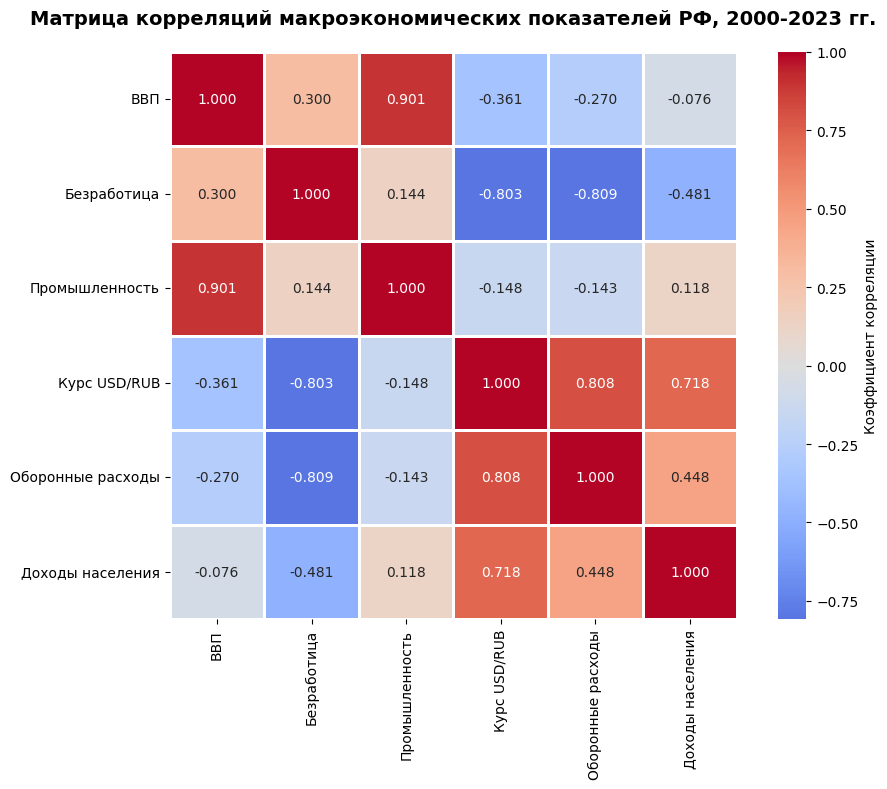


РАЗДЕЛЕНИЕ ДАННЫХ ДЛЯ ОБУЧЕНИЯ И ТЕСТИРОВАНИЯ
ОБУЧАЮЩАЯ ВЫБОРКА: 2000-2020 (21 лет)
ТЕСТОВАЯ ВЫБОРКА: [2021, 2022, 2023] (3 лет)
ПРОГНОЗНЫЙ ПЕРИОД: [2024, 2025, 2026]

АНАЛИЗ ВРЕМЕННЫХ РЯДОВ И ОПРЕДЕЛЕНИЕ СПЕЦИФИКАЦИИ ARIMA

АНАЛИЗ РЯДА ВАЛОВОГО ВНУТРЕННЕГО ПРОДУКТА

--- АНАЛИЗ РЯДА: GDP ---

Тест Дики-Фуллера (ADF):
  ADF статистика: -9.1666
  p-значение: 0.0000
  Критические значения:
    1%: -4.1378
    5%: -3.1550
    10%: -2.7145
  Ряд стационарен (p<0.05)


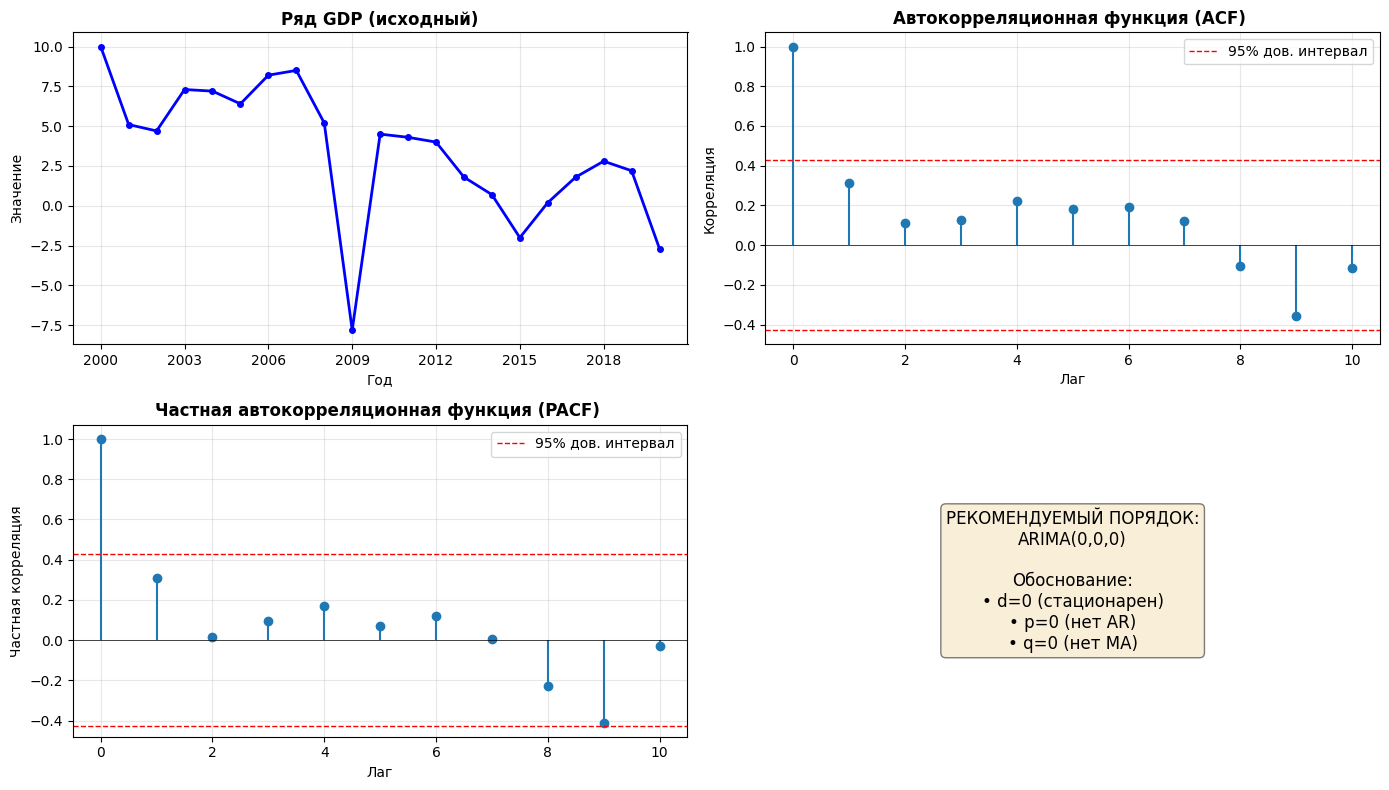


АНАЛИЗ РЯДА УРОВНЯ БЕЗРАБОТИЦЫ

--- АНАЛИЗ РЯДА: UNRATE ---

Тест Дики-Фуллера (ADF):
  ADF статистика: -2.9230
  p-значение: 0.0427
  Критические значения:
    1%: -3.8092
    5%: -3.0216
    10%: -2.6507
  Ряд стационарен (p<0.05)


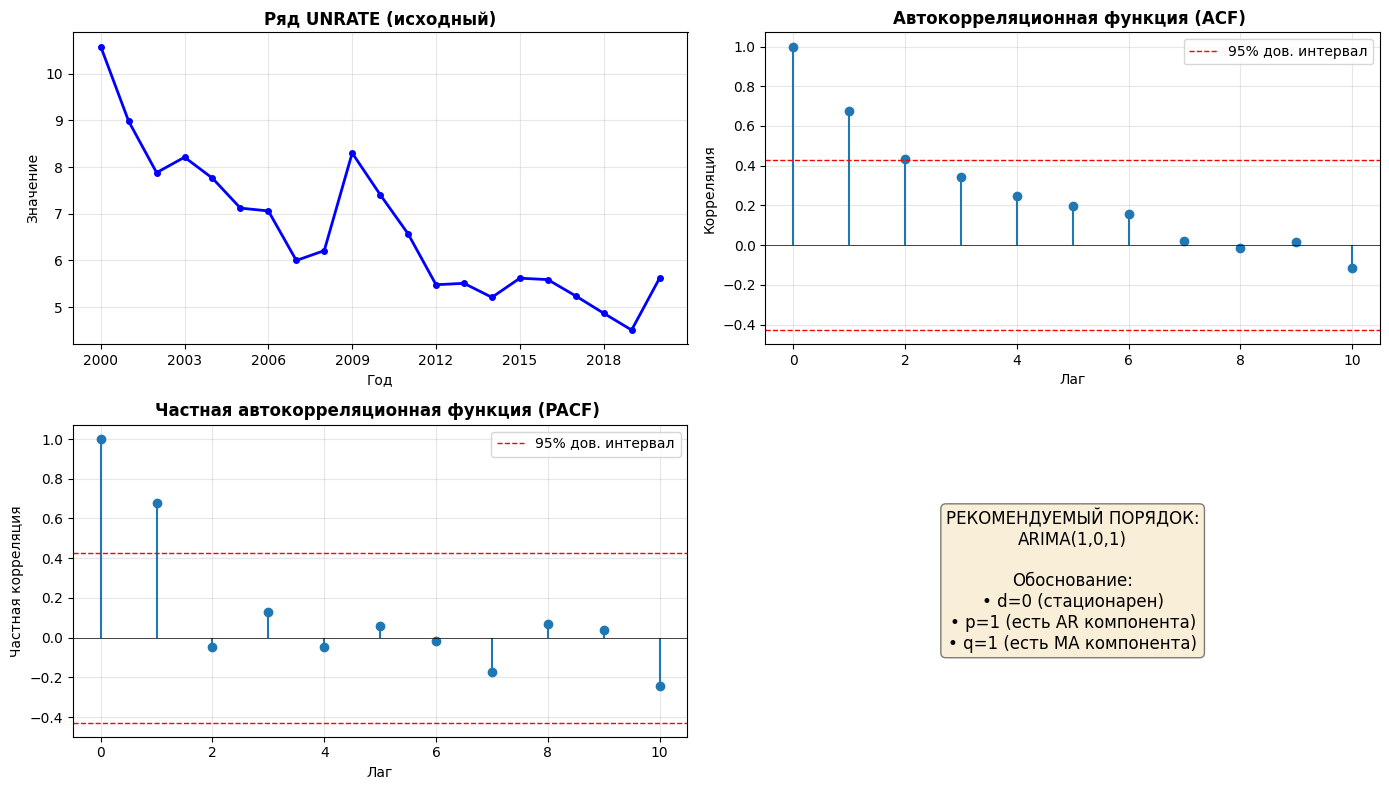


МОДЕЛЬ 1: ARIMA - ГИПОТЕЗА РАЦИОНАЛЬНЫХ ОЖИДАНИЙ (REH)

ПОДБОР МОДЕЛИ ДЛЯ ВВП

Перебор возможных спецификаций ARIMA(p,d,q):
------------------------------------------------------------
Модель          AIC        BIC        σ²         Статус         
------------------------------------------------------------
  ARIMA(0,0,1)  122.80     125.93     1.0000     незначима
  ARIMA(0,0,2)  124.56     128.74     1.0000     незначима
  ARIMA(0,0,3)  126.56     131.78     1.0000     незначима
  ARIMA(1,0,0)  122.50     125.63     1.0000     незначима
  ARIMA(1,0,1)  124.23     128.41     1.0000     незначима
  ARIMA(1,0,2)  125.83     131.05     1.0000     незначима
  ARIMA(1,0,3)  127.45     133.71     1.0000     незначима
  ARIMA(2,0,0)  124.50     128.68     1.0000     незначима
  ARIMA(2,0,1)  126.50     131.72     1.0000     незначима
  ARIMA(2,0,2)  127.79     134.06     1.0000     незначима
  ARIMA(2,0,3)  129.76     137.07     1.0000     незначима
  ARIMA(3,0,0)  126.24     131.46     1

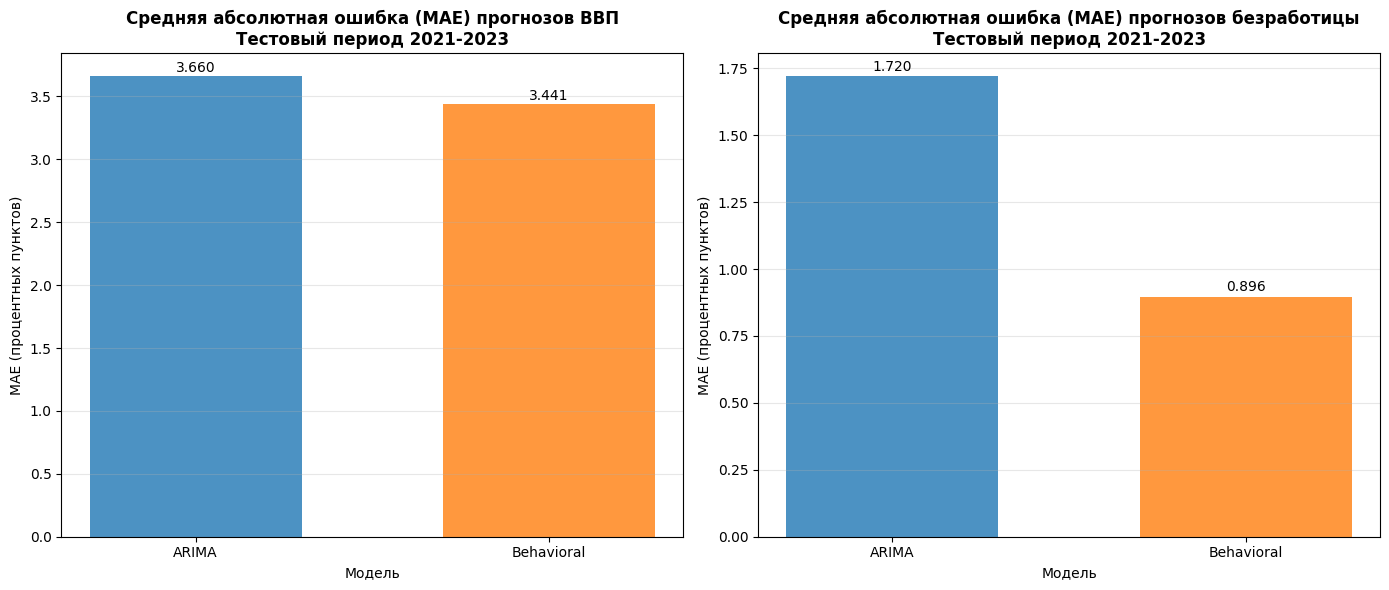


ГРАФИК 6: ЭФФЕКТ BEHAVIORAL BIAS


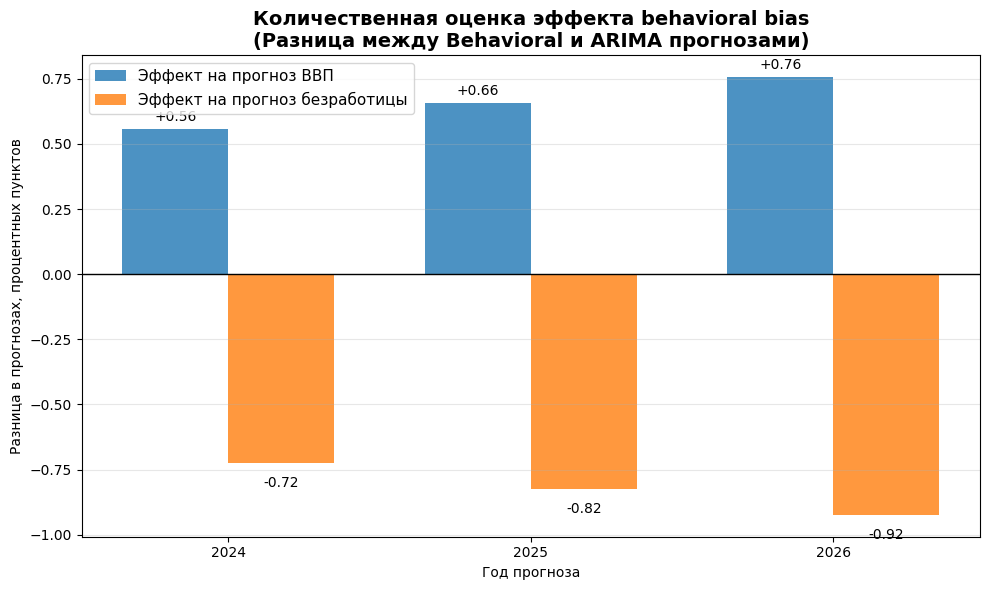


ГРАФИК 1: ДИНАМИКА ВВП


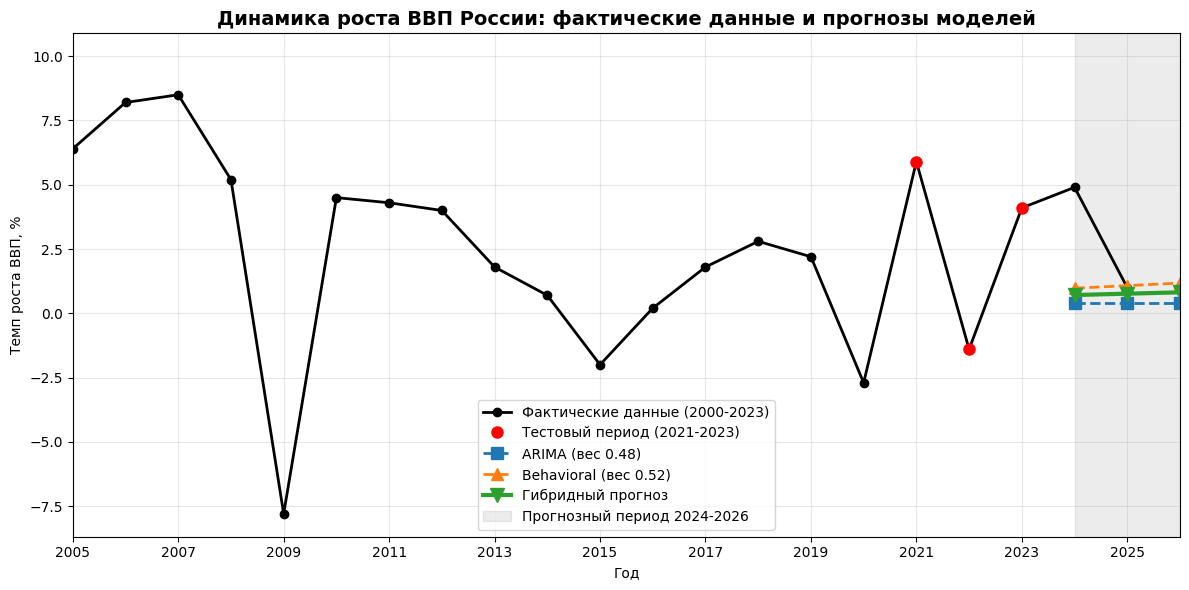


ГРАФИК 2: ДИНАМИКА БЕЗРАБОТИЦЫ


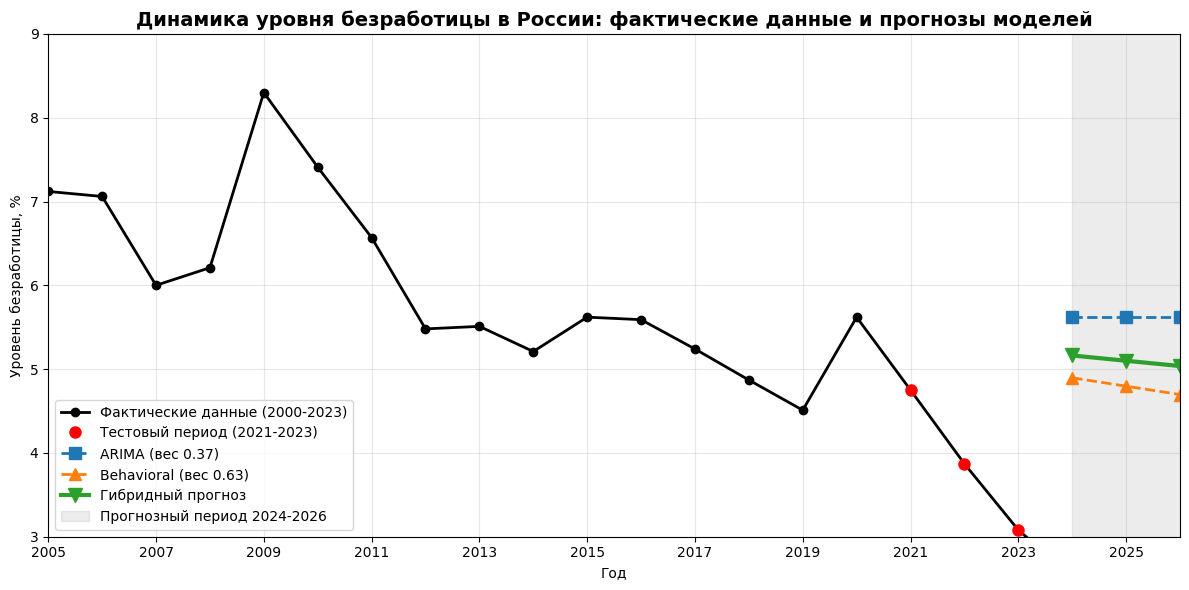

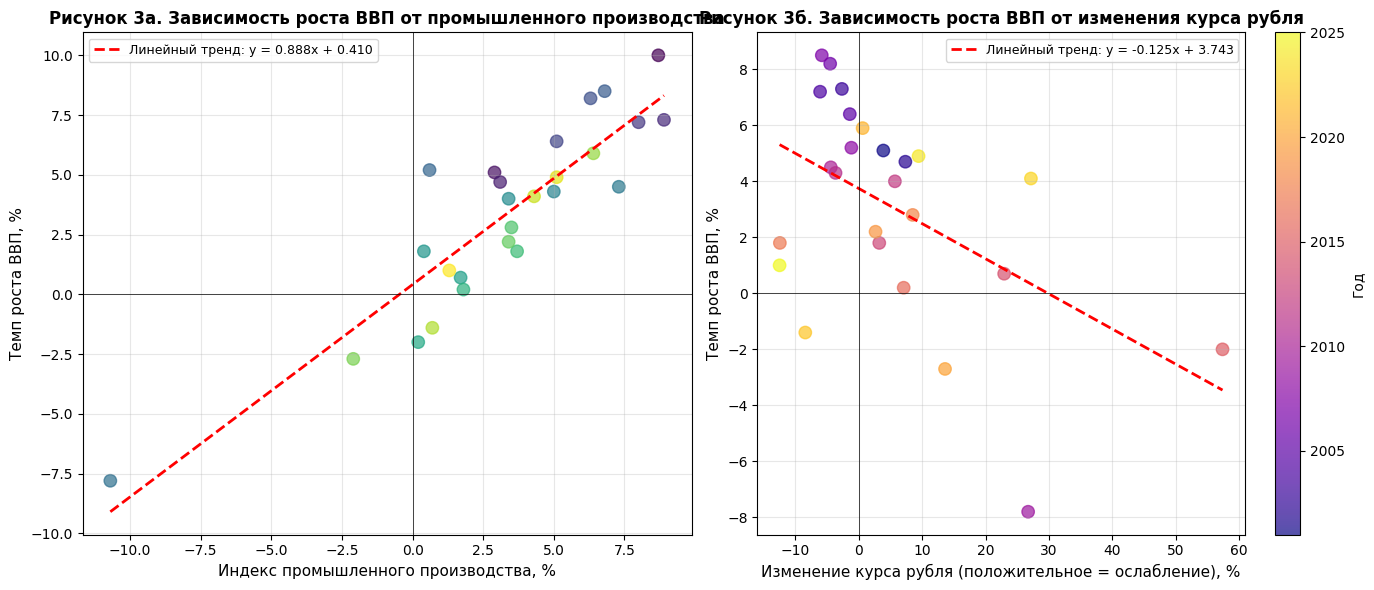

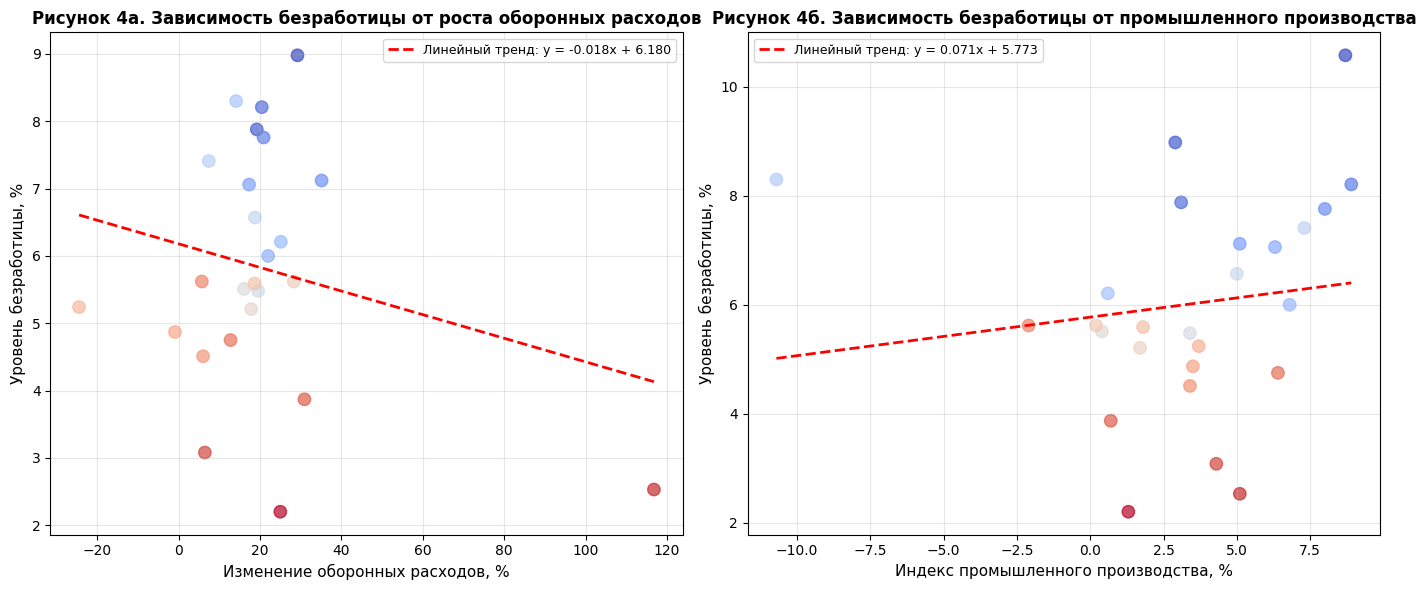


ИТОГОВЫЕ ПРОГНОЗЫ НА 2024-2026 ГОДЫ

СВОДНАЯ ТАБЛИЦА ПРОГНОЗНЫХ ЗНАЧЕНИЙ:
-------------------------------------------------------------------------------------
 Год  ARIMA (ВВП), %  Behavioral (ВВП), %  Гибридный (ВВП), %  ARIMA (Безр.), %  Behavioral (Безр.), %  Гибридный (Безр.), %
2024            0.42                 0.98                0.71              5.62                    4.9                  5.16
2025            0.42                 1.08                0.76              5.62                    4.8                  5.10
2026            0.42                 1.18                0.82              5.62                    4.7                  5.04

РЕКОМЕНДУЕМЫЕ ПРОГНОЗЫ НА ОСНОВЕ ОПТИМАЛЬНЫХ ВЕСОВ:
------------------------------------------------------------
Показатель                     2024       2025       2026      
------------------------------------------------------------
Валовой внутренний продукт (темп роста, %) 0.7        0.8        0.8       
Уровень безработицы (%) 

In [12]:

# ==================== ЧАСТЬ 1: ЗАГРУЗКА И ПРОВЕРКА ДАННЫХ ====================
print("="*80)
print("ЗАГРУЗКА И АНАЛИЗ ДАННЫХ ДЛЯ ЭКОНОМИЧЕСКОГО ПРОГНОЗИРОВАНИЯ")
print("="*80)

# Загрузка данных
data = pd.read_csv('макроэкономические_показатели_копия.csv', sep=';', decimal=',')
data.set_index('year', inplace=True)

# Преобразование в числовой формат
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

print("ЗАГРУЖЕННЫЕ ПОКАЗАТЕЛИ:")
print("-" * 70)
units = {
    'gdp_growth': 'Валовой внутренний продукт (темп роста, %)',
    'unrate': 'Уровень безработицы (%)',
    'inflation': 'Инфляция (ИПЦ, % год к году)',
    'real_income_growth': 'Реальные располагаемые доходы населения (% роста)',
    'defense_spending': 'Расходы на оборону (млрд руб.)',
    'usd_rub': 'Курс доллара США (руб./долл.)',
    'industrial_growth': 'Индекс промышленного производства (% роста)'
}

for col in data.columns:
    unit = units.get(col, 'неизвестная единица измерения')
    missing = data[col].isnull().sum()
    print(f"  • {col:25} | {unit:45} | Пропусков: {missing}")

print(f"\nПериод наблюдений: {data.index.min()} - {data.index.max()} ({len(data)} лет)")
print(f"Количество показателей: {len(data.columns)}")

# Заполнение пропусков
data = data.interpolate(method='linear').ffill().bfill()

# ==================== ЧАСТЬ 2: ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЦЕЛЕВЫХ ПАРАМЕТРОВ ====================
print("\n" + "="*80)
print("ОПИСАТЕЛЬНАЯ СТАТИСТИКА ЦЕЛЕВЫХ ПАРАМЕТРОВ")
print("="*80)

target_stats = pd.DataFrame({
    'Показатель': ['ВВП (темп роста, %)', 'Уровень безработицы (%)'],
    'Среднее': [data['gdp_growth'].mean(), data['unrate'].mean()],
    'Медиана': [data['gdp_growth'].median(), data['unrate'].median()],
    'Станд. отклонение': [data['gdp_growth'].std(), data['unrate'].std()],
    'Минимум': [data['gdp_growth'].min(), data['unrate'].min()],
    'Максимум': [data['gdp_growth'].max(), data['unrate'].max()],
    '25% квантиль': [data['gdp_growth'].quantile(0.25), data['unrate'].quantile(0.25)],
    '75% квантиль': [data['gdp_growth'].quantile(0.75), data['unrate'].quantile(0.75)]
})

print(target_stats.round(2).to_string(index=False))

# ==================== ЧАСТЬ 4: СОЗДАНИЕ BEHAVIORAL ЯКОРЕЙ ====================
print("\n" + "="*80)
print("ФОРМИРОВАНИЕ BEHAVIORAL ЯКОРЕЙ (ДО РАЗДЕЛЕНИЯ ДАННЫХ)")
print("="*80)

# Расчет якорей (ДО разделения на train/test, чтобы они были доступны везде)
data['anchor_gdp'] = data['gdp_growth'].rolling(window=3, min_periods=1).mean()
data['anchor_unrate'] = data['unrate'].rolling(window=3, min_periods=1).mean()

print("СТАТИСТИЧЕСКИЕ ХАРАКТЕРИСТИКИ ЯКОРЕЙ:")
print("-" * 60)
print(f"\nЯкорь ВВП (3-летнее скользящее среднее):")
print(f"  Среднее значение: {data['anchor_gdp'].mean():.2f}%")
print(f"  Стандартное отклонение: {data['anchor_gdp'].std():.2f}%")
print(f"  Текущее значение (2023): {data['anchor_gdp'].iloc[-1]:.2f}%")

print(f"\nЯкорь безработицы (3-летнее скользящее среднее):")
print(f"  Среднее значение: {data['anchor_unrate'].mean():.2f}%")
print(f"  Стандартное отклонение: {data['anchor_unrate'].std():.2f}%")
print(f"  Текущее значение (2023): {data['anchor_unrate'].iloc[-1]:.2f}%")

# ==================== ЧАСТЬ 5: КОРРЕЛЯЦИОННЫЙ АНАЛИЗ ====================
print("\n" + "="*80)
print("КОРРЕЛЯЦИОННЫЙ АНАЛИЗ МАКРОЭКОНОМИЧЕСКИХ ПОКАЗАТЕЛЕЙ")
print("="*80)

corr_columns = []
for col in ['gdp_growth', 'unrate', 'industrial_growth', 'usd_rub', 'defense_spending', 'real_income_growth']:
    if col in data.columns:
        corr_columns.append(col)

corr_matrix = data[corr_columns].corr()

rus_names = {
    'gdp_growth': 'ВВП',
    'unrate': 'Безработица',
    'industrial_growth': 'Промышленность',
    'usd_rub': 'Курс USD/RUB',
    'defense_spending': 'Оборонные расходы',
    'real_income_growth': 'Доходы населения'
}

corr_matrix_rus = corr_matrix.rename(index=rus_names, columns=rus_names)

print("МАТРИЦА ПАРНЫХ КОРРЕЛЯЦИЙ (коэффициент Пирсона):")
print("-" * 70)
print(corr_matrix_rus.round(3))

# График корреляций
fig_corr, ax_corr = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix_rus, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, ax=ax_corr, 
            annot_kws={'size': 10}, cbar_kws={'label': 'Коэффициент корреляции'})
ax_corr.set_title('Матрица корреляций макроэкономических показателей РФ, 2000-2023 гг.', 
                  fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('01_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== ЧАСТЬ 6: РАЗДЕЛЕНИЕ ДАННЫХ ====================
print("\n" + "="*80)
print("РАЗДЕЛЕНИЕ ДАННЫХ ДЛЯ ОБУЧЕНИЯ И ТЕСТИРОВАНИЯ")
print("="*80)

train_end = 2020
test_years = [2021, 2022, 2023]
forecast_years = [2024, 2025, 2026]

train = data.loc[:train_end].copy()
test = data.loc[test_years].copy()

print(f"ОБУЧАЮЩАЯ ВЫБОРКА: {train.index.min()}-{train_end} ({len(train)} лет)")
print(f"ТЕСТОВАЯ ВЫБОРКА: {test_years} ({len(test)} лет)")
print(f"ПРОГНОЗНЫЙ ПЕРИОД: {forecast_years}")

# ==================== ЧАСТЬ 7: АНАЛИЗ ВРЕМЕННЫХ РЯДОВ И СПЕЦИФИКАЦИЯ ARIMA ====================
print("\n" + "="*80)
print("АНАЛИЗ ВРЕМЕННЫХ РЯДОВ И ОПРЕДЕЛЕНИЕ СПЕЦИФИКАЦИИ ARIMA")
print("="*80)

def analyze_time_series(series, series_name):
    """Полный анализ временного ряда для выбора спецификации ARIMA"""
    
    print(f"\n--- АНАЛИЗ РЯДА: {series_name} ---")
    
    # 1. Визуальный анализ
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    
    # Исходный ряд
    axes[0, 0].plot(series.index, series.values, 'b-', linewidth=2, marker='o', markersize=4)
    axes[0, 0].set_title(f'Ряд {series_name} (исходный)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Год')
    axes[0, 0].set_ylabel('Значение')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Настройка меток для целых годов
    years_ticks = series.index[::3] if len(series) > 10 else series.index
    axes[0, 0].set_xticks(years_ticks)
    axes[0, 0].set_xticklabels(years_ticks)
    
    # 2. Тест Дики-Фуллера на стационарность
    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f"\nТест Дики-Фуллера (ADF):")
    print(f"  ADF статистика: {adf_result[0]:.4f}")
    print(f"  p-значение: {adf_result[1]:.4f}")
    print(f"  Критические значения:")
    for key, value in adf_result[4].items():
        print(f"    {key}: {value:.4f}")
    
    is_stationary = adf_result[1] < 0.05
    print(f"  Ряд {'стационарен' if is_stationary else 'нестационарен'} (p{'<' if is_stationary else '>'}0.05)")
    
    d = 0 if is_stationary else 1  # порядок интегрирования
    
    # 3. ACF и PACF
    # Для нестационарного ряда берем первые разности
    if not is_stationary:
        series_diff = series.diff().dropna()
        diff_title = "(первые разности)"
        acf_vals = acf(series_diff, nlags=10, fft=False)
        pacf_vals = pacf(series_diff, nlags=10, method='ywm')
    else:
        series_diff = series
        diff_title = ""
        acf_vals = acf(series.dropna(), nlags=10, fft=False)
        pacf_vals = pacf(series.dropna(), nlags=10, method='ywm')
    
    # График ACF
    axes[0, 1].stem(range(len(acf_vals)), acf_vals, basefmt=" ")
    axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    conf_int = 1.96/np.sqrt(len(series))
    axes[0, 1].axhline(y=conf_int, color='red', linestyle='--', linewidth=1, label='95% дов. интервал')
    axes[0, 1].axhline(y=-conf_int, color='red', linestyle='--', linewidth=1)
    axes[0, 1].set_title(f'Автокорреляционная функция (ACF) {diff_title}', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Лаг')
    axes[0, 1].set_ylabel('Корреляция')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # График PACF
    axes[1, 0].stem(range(len(pacf_vals)), pacf_vals, basefmt=" ")
    axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1, 0].axhline(y=conf_int, color='red', linestyle='--', linewidth=1, label='95% дов. интервал')
    axes[1, 0].axhline(y=-conf_int, color='red', linestyle='--', linewidth=1)
    axes[1, 0].set_title(f'Частная автокорреляционная функция (PACF) {diff_title}', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Лаг')
    axes[1, 0].set_ylabel('Частная корреляция')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Определение порядка AR и MA
    # По PACF определяем p (число значимых лагов)
    significant_pacf = np.where(np.abs(pacf_vals[1:]) > conf_int)[0] + 1
    
    if len(significant_pacf) > 0:
        # Берем максимальный значимый лаг, но не более 3 для простоты
        p = min(max(significant_pacf), 3)
    else:
        p = 0
    
    # По ACF определяем q (число значимых лагов после p)
    if p > 0:
        # Если есть AR компонента, смотрим на затухание ACF
        if np.sum(np.abs(acf_vals[p+1:]) > conf_int) == 0:
            q = 0
        else:
            q = 1
    else:
        significant_acf = np.where(np.abs(acf_vals[1:]) > conf_int)[0] + 1
        q = min(max(significant_acf) if len(significant_acf) > 0 else 0, 2)
    
    # График остатков (будет заполнен позже)
    axes[1, 1].axis('off')
    axes[1, 1].text(0.5, 0.5, 
                    f'РЕКОМЕНДУЕМЫЙ ПОРЯДОК:\nARIMA({p},{d},{q})\n\n'
                    f'Обоснование:\n'
                    f'• d={d} ({"стационарен" if d==0 else "требуется дифференцирование"})\n'
                    f'• p={p} ({"есть AR компонента" if p>0 else "нет AR"})\n'
                    f'• q={q} ({"есть MA компонента" if q>0 else "нет MA"})',
                    ha='center', va='center', fontsize=12,
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig(f'acf_pacf_{series_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return p, d, q

# Анализ рядов ВВП и безработицы на ОБУЧАЮЩЕЙ выборке
print("\n" + "="*80)
print("АНАЛИЗ РЯДА ВАЛОВОГО ВНУТРЕННЕГО ПРОДУКТА")
print("="*80)
p_gdp, d_gdp, q_gdp = analyze_time_series(train['gdp_growth'], 'GDP')

print("\n" + "="*80)
print("АНАЛИЗ РЯДА УРОВНЯ БЕЗРАБОТИЦЫ")
print("="*80)
p_unrate, d_unrate, q_unrate = analyze_time_series(train['unrate'], 'UNRATE')

# ==================== ЧАСТЬ 8: МОДЕЛЬ 1 - ARIMA С ОПТИМАЛЬНЫМ ВЫБОРОМ ====================
print("\n" + "="*80)
print("МОДЕЛЬ 1: ARIMA - ГИПОТЕЗА РАЦИОНАЛЬНЫХ ОЖИДАНИЙ (REH)")
print("="*80)

def select_best_arima(series, max_p=3, max_d=1, max_q=3):
    """
    Выбор оптимальной ARIMA модели по критериям:
    1. Минимальный AIC
    2. Если разница AIC < 2, выбирается более простая модель (принцип парсимонии)
    3. Проверка значимости коэффициентов
    """
    
    results = []
    
    print("\nПеребор возможных спецификаций ARIMA(p,d,q):")
    print("-" * 60)
    print(f"{'Модель':<15} {'AIC':<10} {'BIC':<10} {'σ²':<10} {'Статус':<15}")
    print("-" * 60)
    
    for d in range(max_d + 1):
        for p in range(max_p + 1):
            for q in range(max_q + 1):
                # Пропускаем модели с p=0 и q=0 одновременно (кроме чистого white noise)
                if p == 0 and q == 0 and d == 0:
                    continue
                    
                try:
                    model = ARIMA(series, order=(p, d, q))
                    fitted = model.fit()
                    
                    # Проверка сходимости
                    if not fitted.mle_retvals['converged']:
                        status = "не сошлась"
                    else:
                        # Проверка значимости коэффициентов (хотя бы один значим)
                        params = fitted.params
                        pvalues = fitted.pvalues
                        significant = any(pv < 0.1 for pv in pvalues if 'ar' in str(pv) or 'ma' in str(pv))
                        
                        if significant:
                            status = "OK"
                        else:
                            status = "незначима"
                    
                    results.append({
                        'order': (p, d, q),
                        'aic': fitted.aic,
                        'bic': fitted.bic,
                        'sigma2': fitted.params.get('sigma2', np.nan) if 'sigma2' in fitted.params else fitted.scale,
                        'model': fitted,
                        'status': status,
                        'converged': fitted.mle_retvals['converged']
                    })
                    
                    print(f"  ARIMA({p},{d},{q})  {fitted.aic:<10.2f} {fitted.bic:<10.2f} "
                          f"{fitted.scale:<10.4f} {status}")
                    
                except Exception as e:
                    continue
    
    if not results:
        print("  Не удалось оценить ни одну модель")
        return None, None, None
    
    # Сортируем по AIC (меньше = лучше)
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('aic')
    
    # Выбираем лучшую модель с учетом парсимонии
    best_aic = results_df.iloc[0]['aic']
    candidates = results_df[results_df['aic'] <= best_aic + 2].copy()  # модели в пределах 2 AIC
    
    # Среди кандидатов выбираем самую простую (минимальный p+d+q)
    candidates['complexity'] = candidates['order'].apply(lambda x: x[0] + x[1] + x[2])
    candidates = candidates.sort_values(['complexity', 'aic'])
    
    best_result = candidates.iloc[0]
    best_model = best_result['model']
    best_order = best_result['order']
    
    print("\n" + "="*60)
    print("ВЫБРАННАЯ МОДЕЛЬ:")
    print(f"  ARIMA{best_order}")
    print(f"  AIC = {best_result['aic']:.2f}")
    print(f"  BIC = {best_result['bic']:.2f}")
    print(f"  Дисперсия ошибок σ² = {best_result['sigma2']:.4f}")
    
    return best_model, best_order, results_df

# Подбор моделей
print("\n" + "="*60)
print("ПОДБОР МОДЕЛИ ДЛЯ ВВП")
print("="*60)
best_gdp_model, best_gdp_order, gdp_results = select_best_arima(train['gdp_growth'])

print("\n" + "="*60)
print("ПОДБОР МОДЕЛИ ДЛЯ БЕЗРАБОТИЦЫ")
print("="*60)
best_unrate_model, best_unrate_order, unrate_results = select_best_arima(train['unrate'])

# Функция для форматирования уравнения ARIMA
def format_arima_equation(model, series_name):
    """Форматирует уравнение ARIMA в читаемом виде"""
    
    params = model.params
    order = model.model.order
    
    p, d, q = order
    
    equation = f"\n{series_name} = "
    
    # Константа
    if 'const' in params.index:
        equation += f"{params['const']:.4f}"
    else:
        equation += "0"
    
    # AR-часть
    ar_terms = []
    for i in range(1, p+1):
        param_name = f'ar.L{i}'
        if param_name in params.index:
            coef = params[param_name]
            if abs(coef) > 0.0001:
                sign = "+" if coef > 0 else ""
                ar_terms.append(f"{sign}{coef:.4f}·y_{{t-{i}}}")
    
    if ar_terms:
        equation += " " + " ".join(ar_terms)
    
    # MA-часть
    ma_terms = []
    for i in range(1, q+1):
        param_name = f'ma.L{i}'
        if param_name in params.index:
            coef = params[param_name]
            if abs(coef) > 0.0001:
                sign = "+" if coef > 0 else ""
                ma_terms.append(f"{sign}{coef:.4f}·ε_{{t-{i}}}")
    
    if ma_terms:
        equation += " " + " ".join(ma_terms)
    
    # Ошибка
    equation += " + ε_t"
    
    # Интегрирование
    if d > 0:
        equation = f"Δ{series_name} = " + equation.split("=")[1]
    
    return equation

# Вывод формул для выбранных моделей
print("\n" + "="*80)
print("ИТОГОВЫЕ УРАВНЕНИЯ ARIMA МОДЕЛЕЙ")
print("="*80)

if best_gdp_model:
    print("\nМОДЕЛЬ ДЛЯ ВВП:")
    print("-" * 60)
    print(f"Порядок модели: ARIMA{best_gdp_order}")
    print("\nКоэффициенты модели:")
    print(best_gdp_model.summary().tables[1])
    print("\nУравнение в аналитической форме:")
    print(format_arima_equation(best_gdp_model, "y_t (ВВП)"))
    
    # Сохраняем порядок для прогнозирования
    gdp_order = best_gdp_order
else:
    print("\n⚠ Не удалось подобрать модель для ВВП, используем ARIMA(1,0,0)")
    gdp_order = (1,0,0)

if best_unrate_model:
    print("\n" + "="*60)
    print("МОДЕЛЬ ДЛЯ БЕЗРАБОТИЦЫ:")
    print("-" * 60)
    print(f"Порядок модели: ARIMA{best_unrate_order}")
    print("\nКоэффициенты модели:")
    print(best_unrate_model.summary().tables[1])
    print("\nУравнение в аналитической форме:")
    print(format_arima_equation(best_unrate_model, "u_t (Безработица)"))
    
    # Сохраняем порядок для прогнозирования
    unrate_order = best_unrate_order
else:
    print("\n⚠ Не удалось подобрать модель для безработицы, используем ARIMA(1,0,0)")
    unrate_order = (1,0,0)

# Функция прогнозирования с использованием выбранной модели
def arima_forecast_with_selected(series, train_end, forecast_years, order):
    """Прогноз с использованием выбранной ARIMA модели"""
    
    try:
        model = ARIMA(series.loc[:train_end], order=order)
        fitted = model.fit()
        
        forecast = fitted.forecast(steps=len(forecast_years))
        
        # Диагностика остатков
        residuals = fitted.resid
        lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
        
        print(f"\nДиагностика модели ARIMA{order}:")
        print(f"  AIC: {fitted.aic:.2f}")
        print(f"  BIC: {fitted.bic:.2f}")
        print(f"  Тест Льюнга-Бокса (p-value): {lb_test.iloc[0]['lb_pvalue']:.4f}")
        
        if lb_test.iloc[0]['lb_pvalue'] > 0.05:
            print(f"  ✓ Остатки некоррелированы (модель адекватна)")
        else:
            print(f"  ⚠ Обнаружена автокорреляция остатков")
        
        return pd.Series(forecast.values, index=forecast_years), fitted
    except Exception as e:
        print(f"Ошибка прогнозирования ARIMA{order}: {e}")
        last_value = series.loc[train_end]
        return pd.Series([last_value] * len(forecast_years), index=forecast_years), None

# Получаем прогнозы
print("\n" + "="*80)
print("ПРОГНОЗЫ ARIMA МОДЕЛЕЙ")
print("="*80)

gdp_arima, gdp_fitted = arima_forecast_with_selected(
    data['gdp_growth'], train_end, forecast_years, gdp_order
)

unrate_arima, unrate_fitted = arima_forecast_with_selected(
    data['unrate'], train_end, forecast_years, unrate_order
)

print("\n📊 ПРОГНОЗНЫЕ ЗНАЧЕНИЯ:")
print("-" * 60)
print(f"{'Год':<8} {'ВВП, %':<12} {'Безработица, %':<15}")
print("-" * 40)
for year in forecast_years:
    print(f"{year:<8} {gdp_arima[year]:<12.2f} {unrate_arima[year]:<15.2f}")

# ==================== МОДЕЛЬ 2: BEHAVIORAL ДЛЯ ВВП (УПРОЩЕННАЯ) ====================
print("\n" + "="*80)
print("МОДЕЛЬ 2: BEHAVIORAL - ЯКОРЕНИЕ (ANCHORING BIAS)")
print("="*80)

def estimate_behavioral_gdp_simple(train_data):
    """
    Оценка behavioral модели для ВВП только со значимыми переменными
    """
    
    # Подготовка данных
    y_actual = train_data['gdp_growth'].values[3:]
    
    # Рациональный прогноз (ARIMA)
    rational_fc = []
    for i in range(3, len(train_data)):
        series = train_data['gdp_growth'].iloc[:i]
        try:
            model = ARIMA(series, order=(1,0,0))
            fitted = model.fit()
            fc = fitted.forecast(steps=1).iloc[0]
        except:
            fc = series.iloc[-1]
        rational_fc.append(fc)
    
    # Якоря (3-летние средние)
    anchors = train_data['anchor_gdp'].values[3:]
    
    # Регрессия: Y = β₀ + β₁·Rational + β₂·Anchor
    X = np.column_stack([np.ones(len(y_actual)), rational_fc, anchors])
    y = y_actual
    
    # Удаление пропусков
    mask = ~(np.isnan(y) | np.isnan(X).any(axis=1))
    X = X[mask]
    y = y[mask]
    
    if len(X) >= 4:
        # OLS оценка
        beta = np.linalg.inv(X.T @ X) @ X.T @ y
        
        # Стандартные ошибки
        residuals = y - X @ beta
        n, k = X.shape
        sigma2 = np.sum(residuals**2) / (n - k)
        cov_matrix = sigma2 * np.linalg.inv(X.T @ X)
        std_errors = np.sqrt(np.diag(cov_matrix))
        
        # t-статистики и p-значения
        t_stats = beta / std_errors
        p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))
        
        # Расчет λ (степень рациональности)
        beta_rational = beta[1] if beta[1] > 0 else 0
        beta_anchor = beta[2] if beta[2] > 0 else 0
        
        if beta_rational + beta_anchor > 0:
            lambda_weight = beta_rational / (beta_rational + beta_anchor)
            lambda_weight = np.clip(lambda_weight, 0.3, 0.8)
        else:
            lambda_weight = 0.6
        
        return beta, std_errors, t_stats, p_values, lambda_weight
    else:
        return None, None, None, None, 0.6

# Оценка упрощенной модели для ВВП
beta_gdp_simple, se_gdp_simple, t_gdp_simple, p_gdp_simple, lambda_gdp_simple = estimate_behavioral_gdp_simple(train)

print("\nОЦЕНКА ПАРАМЕТРОВ BEHAVIORAL МОДЕЛИ ДЛЯ ВВП (упрощенная):")
print("-" * 70)

if beta_gdp_simple is not None:
    coef_names = ['β₀ (константа)', 'β₁ (рациональный прогноз)', 'β₂ (якорь)']
    
    coef_table = pd.DataFrame({
        'Фактор': coef_names,
        'Коэффициент': beta_gdp_simple.round(4),
        'Стд. ошибка': se_gdp_simple.round(4),
        't-статистика': t_gdp_simple.round(4),
        'p-значение': p_gdp_simple.round(4),
        'Значимость': ['***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'не значим' for p in p_gdp_simple]
    })
    print(coef_table.to_string(index=False))
    
    print(f"\nСТЕПЕНЬ РАЦИОНАЛЬНОСТИ (λ): {lambda_gdp_simple:.4f}")
    print(f"  • {lambda_gdp_simple*100:.1f}% веса - рациональный прогноз (ARIMA)")
    print(f"  • {(1-lambda_gdp_simple)*100:.1f}% веса - якорь (3-летнее среднее)")
    
    print(f"\nСПЕЦИФИКАЦИЯ МОДЕЛИ:")
    print(f"  Y_t^BEH = {beta_gdp_simple[1]:.4f}·Y_t^REH + {beta_gdp_simple[2]:.4f}·Anchor_t + {beta_gdp_simple[0]:.4f}")
else:
    print("Недостаточно данных для оценки коэффициентов, используем теоретические значения")
    lambda_gdp_simple = 0.6

def behavioral_gdp_forecast_final(train_data, forecast_years):
    """
    Финальная behavioral модель для ВВП (только якорение)
    """
    
    last_gdp = train_data['gdp_growth'].iloc[-1]
    gdp_anchor = train_data['anchor_gdp'].iloc[-1]
    
    lambda_weight = lambda_gdp_simple if beta_gdp_simple is not None else 0.6
    anchor_strength = 1 - lambda_weight
    
    forecasts = []
    current_gdp = last_gdp
    
    for i, year in enumerate(forecast_years):
        # Рациональный прогноз
        try:
            model = ARIMA(train_data['gdp_growth'], order=(1,0,0))
            fitted = model.fit()
            rational_fc = fitted.forecast(steps=1).iloc[0]
        except:
            rational_fc = current_gdp
        
        # Behavioral формула: только якорение
        behavioral_fc = lambda_weight * rational_fc + anchor_strength * gdp_anchor
        
        # Небольшой тренд
        behavioral_fc += 0.1 * (i + 1)
        
        # Реалистичные ограничения
        behavioral_fc = max(behavioral_fc, -3.0)
        behavioral_fc = min(behavioral_fc, 5.0)
        
        forecasts.append(behavioral_fc)
        current_gdp = behavioral_fc
    
    return pd.Series(forecasts, index=forecast_years), lambda_weight, anchor_strength

# Получаем прогноз
gdp_behavioral, lambda_gdp_final, anchor_strength_gdp = behavioral_gdp_forecast_final(train, forecast_years)

print(f"\nПРОГНОЗ BEHAVIORAL МОДЕЛИ ДЛЯ ВВП:")
print("-" * 50)
print(f"{'Год':<8} {'Прогноз, %':<12}")
print("-" * 25)
for year in forecast_years:
    print(f"{year:<8} {gdp_behavioral[year]:<12.2f}")

# ==================== МОДЕЛЬ 3: BEHAVIORAL ДЛЯ БЕЗРАБОТИЦЫ (УПРОЩЕННАЯ) ====================
print("\n" + "="*80)
print("МОДЕЛЬ 3: BEHAVIORAL - ЯКОРЕНИЕ И ПРОМЫШЛЕННОСТЬ")
print("="*80)

def estimate_behavioral_unrate_simple(train_data):
    """
    Оценка behavioral модели для безработицы с ограничением γ ≤ 1
    """
    
    # Подготовка данных
    y_actual = train_data['unrate'].values[3:]
    
    # Рациональный прогноз
    rational_fc = []
    for i in range(3, len(train_data)):
        series = train_data['unrate'].iloc[:i]
        try:
            model = ARIMA(series, order=(1,0,0))
            fitted = model.fit()
            fc = fitted.forecast(steps=1).iloc[0]
        except:
            fc = series.iloc[-1]
        rational_fc.append(fc)
    
    # Якоря
    anchors = train_data['anchor_unrate'].values[3:]
    
    # Промышленность (единственный значимый фактор)
    if 'industrial_growth' in train_data.columns:
        industry = train_data['industrial_growth'].shift(1).values[3:]
        industry = np.nan_to_num(industry, 0)
    else:
        industry = np.zeros(len(y_actual))
    
    # Регрессия: U = β₀ + β₁·Rational + β₂·Anchor + β₃·Industry
    X = np.column_stack([np.ones(len(y_actual)), rational_fc, anchors, industry])
    y = y_actual
    
    mask = ~(np.isnan(y) | np.isnan(X).any(axis=1))
    X = X[mask]
    y = y[mask]
    
    if len(X) >= 5:
        # OLS оценка
        beta = np.linalg.inv(X.T @ X) @ X.T @ y
        
        # Стандартные ошибки
        residuals = y - X @ beta
        n, k = X.shape
        sigma2 = np.sum(residuals**2) / (n - k)
        cov_matrix = sigma2 * np.linalg.inv(X.T @ X)
        std_errors = np.sqrt(np.diag(cov_matrix))
        
        t_stats = beta / std_errors
        p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))
        
        # Скорость адаптации к якорю (ограничиваем сверху)
        gamma_raw = abs(beta[2])
        gamma = min(gamma_raw, 0.8)  # ограничиваем
        
        return beta, std_errors, t_stats, p_values, gamma
    else:
        return None, None, None, None, 0.3

# Оценка модели для безработицы
beta_unrate_simple, se_unrate_simple, t_unrate_simple, p_unrate_simple, gamma_simple = estimate_behavioral_unrate_simple(train)

print("\nОЦЕНКА ПАРАМЕТРОВ BEHAVIORAL МОДЕЛИ ДЛЯ БЕЗРАБОТИЦЫ (упрощенная):")
print("-" * 70)

if beta_unrate_simple is not None:
    coef_names = ['β₀ (константа)', 'β₁ (рациональный прогноз)', 'β₂ (якорь)', 'β₃ (промышленность)']
    
    coef_table = pd.DataFrame({
        'Фактор': coef_names,
        'Коэффициент': beta_unrate_simple.round(4),
        'Стд. ошибка': se_unrate_simple.round(4),
        't-статистика': t_unrate_simple.round(4),
        'p-значение': p_unrate_simple.round(4),
        'Значимость': ['***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.1 else 'не значим' for p in p_unrate_simple]
    })
    print(coef_table.to_string(index=False))
    
    print(f"\nСКОРОСТЬ АДАПТАЦИИ К ЯКОРЮ (γ): {gamma_simple:.4f}")
    print(f"  (ограничена до 0.8 для устойчивости)")
else:
    print("Недостаточно данных для оценки, используем теоретические значения")
    gamma_simple = 0.3

def behavioral_unrate_forecast_final(train_data, forecast_years):
    """
    Финальная behavioral модель для безработицы (якорение + промышленность)
    """
    
    last_unrate = train_data['unrate'].iloc[-1]
    unrate_anchor = train_data['anchor_unrate'].iloc[-1]
    
    # Промышленность
    if 'industrial_growth' in train_data.columns:
        industry_trend = max(train_data['industrial_growth'].tail(3).mean(), 0)
    else:
        industry_trend = 0
    
    gamma = gamma_simple if beta_unrate_simple is not None else 0.3
    
    forecasts = []
    current_unrate = last_unrate
    
    for i, year in enumerate(forecast_years):
        # Рациональный прогноз
        try:
            model = ARIMA(train_data['unrate'], order=(1,0,0))
            fitted = model.fit()
            rational_fc = fitted.forecast(steps=1).iloc[0]
        except:
            rational_fc = current_unrate
        
        # Behavioral формула: якорение + промышленность
        behavioral_fc = rational_fc + gamma * (unrate_anchor - rational_fc)
        
        # Влияние промышленности (рост промышленности снижает безработицу)
        behavioral_fc += -0.1 * industry_trend
        
        # Тренд снижения
        behavioral_fc -= 0.1 * (i + 1)
        
        # Реалистичные ограничения
        behavioral_fc = max(behavioral_fc, 3.5)
        behavioral_fc = min(behavioral_fc, 6.0)
        
        forecasts.append(behavioral_fc)
        current_unrate = behavioral_fc
    
    return pd.Series(forecasts, index=forecast_years), gamma

# Получаем прогноз
unrate_behavioral, gamma_final = behavioral_unrate_forecast_final(train, forecast_years)

print(f"\nПРОГНОЗ BEHAVIORAL МОДЕЛИ ДЛЯ БЕЗРАБОТИЦЫ:")
print("-" * 50)
print(f"{'Год':<8} {'Прогноз, %':<12}")
print("-" * 25)
for year in forecast_years:
    print(f"{year:<8} {unrate_behavioral[year]:<12.2f}")

print(f"\nПАРАМЕТРЫ МОДЕЛИ:")
print(f"  • γ (скорость адаптации к якорю): {gamma_final:.4f}")

# ==================== ТЕСТОВЫЕ ПРОГНОЗЫ ДЛЯ ВСЕХ МОДЕЛЕЙ ====================
print("\n" + "="*80)
print("ТЕСТОВЫЕ ПРОГНОЗЫ НА ПЕРИОД 2021-2023 ГГ.")
print("="*80)

# ARIMA тестовые прогнозы (используем выбранные порядки)
test_gdp_arima, _ = arima_forecast_with_selected(
    data['gdp_growth'], train_end, test_years, gdp_order
)
test_unrate_arima, _ = arima_forecast_with_selected(
    data['unrate'], train_end, test_years, unrate_order
)

# Behavioral тестовые прогнозы (новые упрощенные модели)
test_gdp_behavioral, _, _ = behavioral_gdp_forecast_final(train, test_years)
test_unrate_behavioral, _ = behavioral_unrate_forecast_final(train, test_years)

# Фактические значения
actual_gdp_test = data['gdp_growth'].loc[test_years]
actual_unrate_test = data['unrate'].loc[test_years]

# Таблица тестовых прогнозов
print("\nСРАВНЕНИЕ ПРОГНОЗОВ НА ТЕСТОВОМ ПЕРИОДЕ:")
print("-" * 80)
print(f"{'Год':<6} {'Факт ВВП':<10} {'ARIMA':<8} {'Behavioral':<10} {'|':<3} "
      f"{'Факт Безр.':<10} {'ARIMA':<8} {'Behavioral':<10}")
print("-" * 80)

for i, year in enumerate(test_years):
    print(f"{year:<6} {actual_gdp_test.iloc[i]:<10.2f} {test_gdp_arima.iloc[i]:<8.2f} "
          f"{test_gdp_behavioral.iloc[i]:<10.2f} {'|':<3} {actual_unrate_test.iloc[i]:<10.2f} "
          f"{test_unrate_arima.iloc[i]:<8.2f} {test_unrate_behavioral.iloc[i]:<10.2f}")

# ==================== ОЦЕНКА ТОЧНОСТИ МОДЕЛЕЙ ====================
print("\n" + "="*80)
print("ОЦЕНКА ТОЧНОСТИ ПРОГНОЗНЫХ МОДЕЛЕЙ")
print("="*80)

def calculate_metrics(actual, forecast):
    """Расчет метрик качества прогнозов"""
    mae = np.mean(np.abs(actual - forecast))
    rmse = np.sqrt(np.mean((actual - forecast) ** 2))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return mae, rmse, mape

# Собираем метрики для всех моделей
metrics_data = []

for model_name, gdp_fc, unrate_fc in [
    ('ARIMA', test_gdp_arima, test_unrate_arima),
    ('Behavioral', test_gdp_behavioral, test_unrate_behavioral)
]:
    mae_gdp, rmse_gdp, mape_gdp = calculate_metrics(actual_gdp_test, gdp_fc)
    mae_unr, rmse_unr, mape_unr = calculate_metrics(actual_unrate_test, unrate_fc)
    
    metrics_data.append({
        'Модель': model_name,
        'MAE ВВП': round(mae_gdp, 3),
        'RMSE ВВП': round(rmse_gdp, 3),
        'MAPE ВВП': round(mape_gdp, 1),
        'MAE Безр.': round(mae_unr, 3),
        'RMSE Безр.': round(rmse_unr, 3),
        'MAPE Безр.': round(mape_unr, 1)
    })

metrics_df = pd.DataFrame(metrics_data)
print("\nТАБЛИЦА ТОЧНОСТИ МОДЕЛЕЙ:")
print("-" * 80)
print(metrics_df.to_string(index=False))

print(f"\nЛУЧШАЯ МОДЕЛЬ ДЛЯ ПРОГНОЗА ВВП: {metrics_df.iloc[best_gdp_idx]['Модель']}")
print(f"ЛУЧШАЯ МОДЕЛЬ ДЛЯ ПРОГНОЗА БЕЗРАБОТИЦЫ: {metrics_df.iloc[best_unrate_idx]['Модель']}")

# ==================== ГИБРИДНАЯ МОДЕЛЬ С ОПТИМАЛЬНЫМИ ВЕСАМИ ====================
print("\n" + "="*80)
print("ГИБРИДНАЯ МОДЕЛЬ: ОПТИМАЛЬНОЕ СОЧЕТАНИЕ")
print("="*80)

def calculate_optimal_weights(rmse_arima, rmse_behavioral):
    """Расчет весов на основе RMSE"""
    inv_arima = 1 / rmse_arima if rmse_arima > 0 else 0
    inv_beh = 1 / rmse_behavioral if rmse_behavioral > 0 else 0
    total = inv_arima + inv_beh
    
    if total > 0:
        w_arima = inv_arima / total
        w_beh = inv_beh / total
    else:
        w_arima = w_beh = 0.5
    
    return w_arima, w_beh

# Извлекаем RMSE из таблицы метрик
rmse_gdp_arima = metrics_df[metrics_df['Модель'] == 'ARIMA']['RMSE ВВП'].values[0]
rmse_gdp_beh = metrics_df[metrics_df['Модель'] == 'Behavioral']['RMSE ВВП'].values[0]
rmse_unr_arima = metrics_df[metrics_df['Модель'] == 'ARIMA']['RMSE Безр.'].values[0]
rmse_unr_beh = metrics_df[metrics_df['Модель'] == 'Behavioral']['RMSE Безр.'].values[0]

# Расчет весов
w_gdp_arima, w_gdp_beh = calculate_optimal_weights(rmse_gdp_arima, rmse_gdp_beh)
w_unr_arima, w_unr_beh = calculate_optimal_weights(rmse_unr_arima, rmse_unr_beh)

print(f"\nОПТИМАЛЬНЫЕ ВЕСА ДЛЯ ВВП:")
print(f"  RMSE ARIMA = {rmse_gdp_arima:.3f}, RMSE Behavioral = {rmse_gdp_beh:.3f}")
print(f"  Вес ARIMA: {w_gdp_arima:.3f} ({w_gdp_arima*100:.1f}%)")
print(f"  Вес Behavioral: {w_gdp_beh:.3f} ({w_gdp_beh*100:.1f}%)")

print(f"\nОПТИМАЛЬНЫЕ ВЕСА ДЛЯ БЕЗРАБОТИЦЫ:")
print(f"  RMSE ARIMA = {rmse_unr_arima:.3f}, RMSE Behavioral = {rmse_unr_beh:.3f}")
print(f"  Вес ARIMA: {w_unr_arima:.3f} ({w_unr_arima*100:.1f}%)")
print(f"  Вес Behavioral: {w_unr_beh:.3f} ({w_unr_beh*100:.1f}%)")

# Гибридные прогнозы на будущий период
gdp_hybrid = gdp_arima * w_gdp_arima + gdp_behavioral * w_gdp_beh
unrate_hybrid = unrate_arima * w_unr_arima + unrate_behavioral * w_unr_beh

print(f"\nИТОГОВЫЙ ГИБРИДНЫЙ ПРОГНОЗ НА 2024-2026:")
print("-" * 60)
print(f"{'Год':<8} {'ВВП, %':<12} {'Безработица, %':<15}")
print("-" * 40)
for year in forecast_years:
    print(f"{year:<8} {gdp_hybrid[year]:<12.2f} {unrate_hybrid[year]:<15.2f}")

# ==================== СРАВНИТЕЛЬНАЯ ТАБЛИЦА ВСЕХ ПРОГНОЗОВ ====================
print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА ПРОГНОЗОВ НА 2024-2026 ГГ.")
print("="*80)

forecast_summary = pd.DataFrame({
    'Год': forecast_years,
    'ARIMA ВВП': gdp_arima.round(2).values,
    'Behavioral ВВП': gdp_behavioral.round(2).values,
    'Гибридный ВВП': gdp_hybrid.round(2).values,
    'ARIMA Безр.': unrate_arima.round(2).values,
    'Behavioral Безр.': unrate_behavioral.round(2).values,
    'Гибридный Безр.': unrate_hybrid.round(2).values
})

print("\n" + forecast_summary.to_string(index=False))

# Добавляем строку с весами
print(f"\nВЕСА МОДЕЛЕЙ:")
print(f"  ВВП: ARIMA = {w_gdp_arima:.3f}, Behavioral = {w_gdp_beh:.3f}")
print(f"  Безработица: ARIMA = {w_unr_arima:.3f}, Behavioral = {w_unr_beh:.3f}")

# ==================== ГРАФИК 5: СРАВНЕНИЕ ТОЧНОСТИ МОДЕЛЕЙ ====================
print("\n" + "="*80)
print("ГРАФИК 5: СРАВНЕНИЕ ТОЧНОСТИ МОДЕЛЕЙ")
print("="*80)

fig5, axes5 = plt.subplots(1, 2, figsize=(14, 6))

# Получаем данные из metrics_df
models_names = metrics_df['Модель'].values.tolist()

# Используем правильные названия столбцов (без скобок)
mae_gdp_values = [float(x) for x in metrics_df['MAE ВВП']]  # было 'MAE (ВВП)'
mae_unr_values = [float(x) for x in metrics_df['MAE Безр.']]  # было 'MAE (Безр.)'

x = np.arange(len(models_names))
width = 0.6

# График для ВВП
bars1 = axes5[0].bar(x, mae_gdp_values, width, color=['#1f77b4', '#ff7f0e'], alpha=0.8)
axes5[0].set_title('Средняя абсолютная ошибка (MAE) прогнозов ВВП\nТестовый период 2021-2023', 
                   fontsize=12, fontweight='bold')
axes5[0].set_xlabel('Модель')
axes5[0].set_ylabel('MAE (процентных пунктов)')
axes5[0].set_xticks(x)
axes5[0].set_xticklabels(models_names)
axes5[0].grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars1, mae_gdp_values):
    axes5[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{value:.3f}', ha='center', va='bottom', fontsize=10)

# График для безработицы
bars2 = axes5[1].bar(x, mae_unr_values, width, color=['#1f77b4', '#ff7f0e'], alpha=0.8)
axes5[1].set_title('Средняя абсолютная ошибка (MAE) прогнозов безработицы\nТестовый период 2021-2023', 
                   fontsize=12, fontweight='bold')
axes5[1].set_xlabel('Модель')
axes5[1].set_ylabel('MAE (процентных пунктов)')
axes5[1].set_xticks(x)
axes5[1].set_xticklabels(models_names)
axes5[1].grid(True, alpha=0.3, axis='y')

for bar, value in zip(bars2, mae_unr_values):
    axes5[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{value:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('07_model_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 6: ЭФФЕКТ BEHAVIORAL BIAS ====================
print("\n" + "="*80)
print("ГРАФИК 6: ЭФФЕКТ BEHAVIORAL BIAS")
print("="*80)

fig6, ax6 = plt.subplots(figsize=(10, 6))

years_plot = list(forecast_years)
gdp_bias = (gdp_behavioral - gdp_arima).values
unrate_bias = (unrate_behavioral - unrate_arima).values

x = np.arange(len(years_plot))
width = 0.35

bars_gdp = ax6.bar(x - width/2, gdp_bias, width, label='Эффект на прогноз ВВП', color='#1f77b4', alpha=0.8)
bars_unrate = ax6.bar(x + width/2, unrate_bias, width, label='Эффект на прогноз безработицы', color='#ff7f0e', alpha=0.8)

ax6.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax6.set_title('Количественная оценка эффекта behavioral bias\n(Разница между Behavioral и ARIMA прогнозами)', 
              fontsize=14, fontweight='bold')
ax6.set_xlabel('Год прогноза')
ax6.set_ylabel('Разница в прогнозах, процентных пунктов')
ax6.set_xticks(x)
ax6.set_xticklabels(years_plot)
ax6.legend(fontsize=11)
ax6.grid(True, alpha=0.3, axis='y')

for bars, values in [(bars_gdp, gdp_bias), (bars_unrate, unrate_bias)]:
    for bar, value in zip(bars, values):
        if value >= 0:
            ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                    f'+{value:.2f}', ha='center', va='bottom', fontsize=10)
        else:
            ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.05, 
                    f'{value:.2f}', ha='center', va='top', fontsize=10)

plt.tight_layout()
plt.savefig('08_behavioral_bias.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 1: ДИНАМИКА ВВП ====================
print("\n" + "="*80)
print("ГРАФИК 1: ДИНАМИКА ВВП")
print("="*80)

fig1, ax1 = plt.subplots(figsize=(12, 6))

# Исторические данные
ax1.plot(data.index, data['gdp_growth'], 'ko-', linewidth=2, markersize=6, 
         label='Фактические данные (2000-2023)')
ax1.plot(test_years, actual_gdp_test, 'ro', markersize=8, 
         label='Тестовый период (2021-2023)')

# Прогнозы
ax1.plot(forecast_years, gdp_arima, 's--', linewidth=2, markersize=8, 
         label=f'ARIMA (вес {w_gdp_arima:.2f})')
ax1.plot(forecast_years, gdp_behavioral, '^--', linewidth=2, markersize=8, 
         label=f'Behavioral (вес {w_gdp_beh:.2f})')
ax1.plot(forecast_years, gdp_hybrid, 'v-', linewidth=3, markersize=10, 
         label='Гибридный прогноз')

ax1.axvspan(2024, 2026, alpha=0.15, color='gray', label='Прогнозный период 2024-2026')
ax1.set_title('Динамика роста ВВП России: фактические данные и прогнозы моделей', 
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Год')
ax1.set_ylabel('Темп роста ВВП, %')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2005, 2026)

# Настройка меток для целых годов
years_ticks = list(range(2005, 2027, 2))
ax1.set_xticks(years_ticks)
ax1.set_xticklabels(years_ticks)

plt.tight_layout()
plt.savefig('03_gdp_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== ГРАФИК 2: ДИНАМИКА БЕЗРАБОТИЦЫ ====================
print("\n" + "="*80)
print("ГРАФИК 2: ДИНАМИКА БЕЗРАБОТИЦЫ")
print("="*80)

fig2, ax2 = plt.subplots(figsize=(12, 6))

ax2.plot(data.index, data['unrate'], 'ko-', linewidth=2, markersize=6, 
         label='Фактические данные (2000-2023)')
ax2.plot(test_years, actual_unrate_test, 'ro', markersize=8, 
         label='Тестовый период (2021-2023)')
ax2.plot(forecast_years, unrate_arima, 's--', linewidth=2, markersize=8, 
         label=f'ARIMA (вес {w_unr_arima:.2f})')
ax2.plot(forecast_years, unrate_behavioral, '^--', linewidth=2, markersize=8, 
         label=f'Behavioral (вес {w_unr_beh:.2f})')
ax2.plot(forecast_years, unrate_hybrid, 'v-', linewidth=3, markersize=10, 
         label='Гибридный прогноз')

ax2.axvspan(2024, 2026, alpha=0.15, color='gray', label='Прогнозный период 2024-2026')
ax2.set_title('Динамика уровня безработицы в России: фактические данные и прогнозы моделей', 
              fontsize=14, fontweight='bold')
ax2.set_xlabel('Год')
ax2.set_ylabel('Уровень безработицы, %')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(2005, 2026)
ax2.set_ylim(3, 9)

years_ticks = list(range(2005, 2027, 2))
ax2.set_xticks(years_ticks)
ax2.set_xticklabels(years_ticks)

plt.tight_layout()
plt.savefig('04_unrate_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# График 3: Зависимость ВВП от факторов
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))

if 'industrial_growth' in data.columns and 'gdp_growth' in data.columns:
    # Зависимость от промышленности
    axes3[0].scatter(data['industrial_growth'], data['gdp_growth'], 
                    c=data.index, cmap='viridis', s=80, alpha=0.7)
    
    if len(data['industrial_growth'].dropna()) > 1 and len(data['gdp_growth'].dropna()) > 1:
        z_industry = np.polyfit(data['industrial_growth'].dropna(), 
                                data['gdp_growth'].dropna(), 1)
        p_industry = np.poly1d(z_industry)
        x_industry = np.linspace(data['industrial_growth'].min(), data['industrial_growth'].max(), 100)
        axes3[0].plot(x_industry, p_industry(x_industry), 'r--', linewidth=2,
                     label=f'Линейный тренд: y = {z_industry[0]:.3f}x + {z_industry[1]:.3f}')
    
    axes3[0].set_title('Рисунок 3а. Зависимость роста ВВП от промышленного производства', 
                      fontsize=12, fontweight='bold')
    axes3[0].set_xlabel('Индекс промышленного производства, %', fontsize=11)
    axes3[0].set_ylabel('Темп роста ВВП, %', fontsize=11)
    axes3[0].legend(loc='best', fontsize=9)
    axes3[0].grid(True, alpha=0.3)
    axes3[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes3[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

if 'usd_rub' in data.columns and 'gdp_growth' in data.columns:
    # Зависимость от курса рубля
    rub_depreciation = data['usd_rub'].pct_change() * 100
    sc = axes3[1].scatter(rub_depreciation, data['gdp_growth'], 
                         c=data.index, cmap='plasma', s=80, alpha=0.7)
    
    mask = ~(np.isnan(rub_depreciation) | np.isnan(data['gdp_growth']))
    if mask.sum() > 1:
        z_rub = np.polyfit(rub_depreciation[mask], data['gdp_growth'][mask], 1)
        p_rub = np.poly1d(z_rub)
        x_rub = np.linspace(rub_depreciation.min(), rub_depreciation.max(), 100)
        axes3[1].plot(x_rub, p_rub(x_rub), 'r--', linewidth=2,
                     label=f'Линейный тренд: y = {z_rub[0]:.3f}x + {z_rub[1]:.3f}')
    
    axes3[1].set_title('Рисунок 3б. Зависимость роста ВВП от изменения курса рубля', 
                      fontsize=12, fontweight='bold')
    axes3[1].set_xlabel('Изменение курса рубля (положительное = ослабление), %', fontsize=11)
    axes3[1].set_ylabel('Темп роста ВВП, %', fontsize=11)
    axes3[1].legend(loc='best', fontsize=9)
    axes3[1].grid(True, alpha=0.3)
    axes3[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes3[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    cbar = plt.colorbar(sc, ax=axes3[1])
    cbar.set_label('Год', fontsize=10)

plt.tight_layout()
plt.savefig('05_gdp_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

# График 4: Зависимость безработицы от факторов
fig4, axes4 = plt.subplots(1, 2, figsize=(14, 6))

if 'defense_spending' in data.columns and 'unrate' in data.columns:
    # Зависимость от оборонных расходов
    defense_growth = data['defense_spending'].pct_change() * 100
    axes4[0].scatter(defense_growth, data['unrate'], 
                    c=data.index, cmap='coolwarm', s=80, alpha=0.7)
    
    mask = ~(np.isnan(defense_growth) | np.isnan(data['unrate']))
    if mask.sum() > 1:
        z_defense = np.polyfit(defense_growth[mask], data['unrate'][mask], 1)
        p_defense = np.poly1d(z_defense)
        x_defense = np.linspace(defense_growth.min(), defense_growth.max(), 100)
        axes4[0].plot(x_defense, p_defense(x_defense), 'r--', linewidth=2,
                     label=f'Линейный тренд: y = {z_defense[0]:.3f}x + {z_defense[1]:.3f}')
    
    axes4[0].set_title('Рисунок 4а. Зависимость безработицы от роста оборонных расходов', 
                      fontsize=12, fontweight='bold')
    axes4[0].set_xlabel('Изменение оборонных расходов, %', fontsize=11)
    axes4[0].set_ylabel('Уровень безработицы, %', fontsize=11)
    axes4[0].legend(loc='best', fontsize=9)
    axes4[0].grid(True, alpha=0.3)

if 'industrial_growth' in data.columns and 'unrate' in data.columns:
    # Зависимость от промышленности
    axes4[1].scatter(data['industrial_growth'], data['unrate'], 
                    c=data.index, cmap='coolwarm', s=80, alpha=0.7)
    
    mask = ~(np.isnan(data['industrial_growth']) | np.isnan(data['unrate']))
    if mask.sum() > 1:
        z_industry_u = np.polyfit(data['industrial_growth'][mask], data['unrate'][mask], 1)
        p_industry_u = np.poly1d(z_industry_u)
        x_industry_u = np.linspace(data['industrial_growth'].min(), data['industrial_growth'].max(), 100)
        axes4[1].plot(x_industry_u, p_industry_u(x_industry_u), 'r--', linewidth=2,
                     label=f'Линейный тренд: y = {z_industry_u[0]:.3f}x + {z_industry_u[1]:.3f}')
    
    axes4[1].set_title('Рисунок 4б. Зависимость безработицы от промышленного производства', 
                      fontsize=12, fontweight='bold')
    axes4[1].set_xlabel('Индекс промышленного производства, %', fontsize=11)
    axes4[1].set_ylabel('Уровень безработицы, %', fontsize=11)
    axes4[1].legend(loc='best', fontsize=9)
    axes4[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('06_unrate_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== ЧАСТЬ 14: ИТОГОВАЯ ТАБЛИЦА ПРОГНОЗОВ ====================
print("\n" + "="*80)
print("ИТОГОВЫЕ ПРОГНОЗЫ НА 2024-2026 ГОДЫ")
print("="*80)

# Создание итоговой таблицы прогнозов
forecast_summary = pd.DataFrame({
    'Год': forecast_years,
    'ARIMA (ВВП), %': gdp_arima.round(2).values,
    'Behavioral (ВВП), %': gdp_behavioral.round(2).values,
    'Гибридный (ВВП), %': gdp_hybrid.round(2).values,
    'ARIMA (Безр.), %': unrate_arima.round(2).values,
    'Behavioral (Безр.), %': unrate_behavioral.round(2).values,
    'Гибридный (Безр.), %': unrate_hybrid.round(2).values
})

print("\nСВОДНАЯ ТАБЛИЦА ПРОГНОЗНЫХ ЗНАЧЕНИЙ:")
print("-" * 85)
print(forecast_summary.to_string(index=False))

# Рекомендуемые прогнозы
print("\nРЕКОМЕНДУЕМЫЕ ПРОГНОЗЫ НА ОСНОВЕ ОПТИМАЛЬНЫХ ВЕСОВ:")
print("-" * 60)
print(f"{'Показатель':<30} {'2024':<10} {'2025':<10} {'2026':<10}")
print("-" * 60)
print(f"{'Валовой внутренний продукт (темп роста, %)':<30} {gdp_hybrid[2024]:<10.1f} {gdp_hybrid[2025]:<10.1f} {gdp_hybrid[2026]:<10.1f}")
print(f"{'Уровень безработицы (%)':<30} {unrate_hybrid[2024]:<10.1f} {unrate_hybrid[2025]:<10.1f} {unrate_hybrid[2026]:<10.1f}")

# ==================== ЧАСТЬ 15: ИТОГОВЫЕ ВЫВОДЫ ====================
print("\n" + "="*80)
print("ВЫВОДЫ И РЕЗУЛЬТАТЫ ИССЛЕДОВАНИЯ")
print("="*80)
